# 04. Diagnostics and paper figures for the R=2 common-eps model

This notebook integrates the former `04_visual_diagnostics_R2.ipynb` and `04P_paper_only_figures_R2.ipynb` into a compact public workflow.

It does **not** refit the Bayesian model. It reads the R=2 common-eps posterior generated by `03_factor_selection_common_eps.ipynb`, then regenerates the main diagnostic figures and tables used in the paper.

Data loading policy:

```text
./data/SP_monthly_sector_and_all.csv  -> real/proprietary data, if available
./data/SAMPLE.csv                     -> synthetic workflow-demonstration data, otherwise
./pdata/SP_monthly_sector_and_all.csv -> fallback copy written by 03, if available
```

If the real file is present, the figures reproduce the paper outputs. If only `SAMPLE.csv` is present, the notebook demonstrates the workflow but does not reproduce the paper's empirical results.

Outputs are saved to:

```text
figures/
tables/
```


In [1]:
# ============================================================
# 0. Setup
# ============================================================

from pathlib import Path
import warnings

import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import arviz as az

from scipy.stats import norm, gaussian_kde, rankdata

warnings.filterwarnings("ignore")

SEED = 123
rng = np.random.default_rng(SEED + 505)

DATA_DIR = Path("./data")
PDATA_DIR = Path("./pdata")
FIG_DIR = Path("./figures")
TABLE_DIR = Path("./tables")

FIG_DIR.mkdir(parents=True, exist_ok=True)
TABLE_DIR.mkdir(parents=True, exist_ok=True)

REAL_INPUT_PATH = DATA_DIR / "SP_monthly_sector_and_all.csv"
SAMPLE_INPUT_PATH = DATA_DIR / "SAMPLE.csv"
PDATA_INPUT_PATH = PDATA_DIR / "SP_monthly_sector_and_all.csv"

if REAL_INPUT_PATH.exists():
    INPUT_PATH = REAL_INPUT_PATH
    DATA_SOURCE = "real"
elif SAMPLE_INPUT_PATH.exists():
    INPUT_PATH = SAMPLE_INPUT_PATH
    DATA_SOURCE = "sample"
elif PDATA_INPUT_PATH.exists():
    INPUT_PATH = PDATA_INPUT_PATH
    DATA_SOURCE = "pdata_fallback"
else:
    raise FileNotFoundError(
        "No input CSV found. Put either ./data/SP_monthly_sector_and_all.csv "
        "or ./data/SAMPLE.csv in the repository."
    )

FINAL_IDATA_CANDIDATES = [
    # Main R=2 alias written by 03_factor_sweep_ar1_binomial_common_eps_clean_v2.ipynb
    PDATA_DIR / "idata_fixed_k1_eigenvalue_eigenvector_R2_common_eps.nc",
    # Direct sweep output written by the same 03 v2 notebook
    PDATA_DIR / "idata_fixed_k1_eigenvalue_eigenvector_common_eps_R2.nc",
    # Optional short fallback for manually renamed files
    PDATA_DIR / "idata_R2_common_eps.nc",
]

MODEL_TAG = "04P_paper_only_R2_common_eps"

K_LIST = [1, 2, 3, 4, 6, 12]
N_PPC_DRAWS = 800
P_MIN = 1e-10
P_MAX = 1.0 - 1e-10
MAX_COPULA_POINTS = 60000

plt.rcParams.update({
    "font.size": 11,
    "axes.labelsize": 12,
    "xtick.labelsize": 10,
    "ytick.labelsize": 10,
    "legend.fontsize": 10,
    "axes.linewidth": 1.0,
    "xtick.direction": "in",
    "ytick.direction": "in",
    "pdf.fonttype": 42,
    "ps.fonttype": 42,
})


def clip_prob(p, p_min=P_MIN, p_max=P_MAX):
    return np.clip(p, p_min, p_max)


def save_figure(fig, stem, dpi=300):
    png_path = FIG_DIR / f"{stem}.png"
    pdf_path = FIG_DIR / f"{stem}.pdf"
    fig.savefig(png_path, dpi=dpi, bbox_inches="tight")
    fig.savefig(pdf_path, bbox_inches="tight")
    print("Saved:", png_path)
    print("Saved:", pdf_path)


def check_required_columns(df, required, df_name="dataframe"):
    missing = set(required) - set(df.columns)
    if missing:
        raise ValueError(f"{df_name} is missing required columns: {sorted(missing)}")


def safe_corrcoef(X):
    C = np.corrcoef(X, rowvar=False)
    C = 0.5 * (C + C.T)
    np.fill_diagonal(C, 1.0)
    return C


def read_required_file(path, label):
    if not path.exists():
        raise FileNotFoundError(f"{label} not found: {path}")
    if path.stat().st_size == 0:
        raise RuntimeError(f"{label} is empty: {path}")
    return path


def resolve_first_existing_path(candidates, label):
    for path in candidates:
        if path.exists() and path.stat().st_size > 0:
            return path
    msg = [f"{label} not found. Checked:"]
    msg += [f"  - {p}" for p in candidates]
    raise FileNotFoundError("\n".join(msg))


FINAL_IDATA_PATH = resolve_first_existing_path(
    FINAL_IDATA_CANDIDATES,
    "R=2 common-eps posterior idata",
)

print("DATA_SOURCE:", DATA_SOURCE)
print("INPUT_PATH:", INPUT_PATH)
print("FINAL_IDATA_PATH:", FINAL_IDATA_PATH)
print("FIG_DIR:", FIG_DIR)
print("TABLE_DIR:", TABLE_DIR)


DATA_SOURCE: real
INPUT_PATH: data\SP_monthly_sector_and_all.csv
FINAL_IDATA_PATH: pdata\idata_fixed_k1_eigenvalue_eigenvector_R2_common_eps.nc
FIG_DIR: figures
TABLE_DIR: tables


## 1. Load monthly panel and saved R=2 posterior

In [2]:
# ============================================================
# 1. Load monthly multi-sector data and R=2 common-eps posterior
# ============================================================

read_required_file(INPUT_PATH, "monthly multi-sector input")
read_required_file(FINAL_IDATA_PATH, "R=2 common-eps posterior idata")

df_ms = pd.read_csv(INPUT_PATH)
check_required_columns(df_ms, ["date", "sector", "bonds", "defaulted"], df_name="df_ms")

df_ms = df_ms.copy()
df_ms["date"] = pd.to_datetime(df_ms["date"])
df_ms = df_ms.sort_values(["sector", "date"]).reset_index(drop=True)
df_ms["default_rate"] = df_ms["defaulted"] / df_ms["bonds"]

all_sectors = sorted(df_ms["sector"].unique())
MODEL_SECTORS = [s for s in all_sectors if s != "ALL"]
sector_labels = list(MODEL_SECTORS)

panel_L = (
    df_ms[df_ms["sector"].isin(MODEL_SECTORS)]
    .pivot(index="date", columns="sector", values="defaulted")
    .sort_index()
)
panel_N = (
    df_ms[df_ms["sector"].isin(MODEL_SECTORS)]
    .pivot(index="date", columns="sector", values="bonds")
    .sort_index()
)

common_index = panel_L.dropna(axis=0, how="any").index.intersection(
    panel_N.dropna(axis=0, how="any").index
)
panel_L = panel_L.loc[common_index, MODEL_SECTORS].astype(int)
panel_N = panel_N.loc[common_index, MODEL_SECTORS].astype(int)
panel_rate = panel_L / panel_N

L_obs = panel_L.to_numpy(dtype=int)
N_obs = panel_N.to_numpy(dtype=int)
date_index = pd.to_datetime(panel_L.index)
T, D = L_obs.shape

idata_final = az.from_netcdf(FINAL_IDATA_PATH)

print("DATA_SOURCE:", DATA_SOURCE)
print("T months:", T)
print("D sectors:", D)
print("sectors:", MODEL_SECTORS)
print("posterior variables:", list(idata_final.posterior.data_vars))

display(panel_rate.head())


DATA_SOURCE: real
T months: 489
D sectors: 13
sectors: ['Consumer', 'Energy', 'FI', 'Forest', 'Health', 'High Tech', 'Insurance', 'Leisure', 'Metal', 'Real Estate', 'Telecom', 'Transport', 'Utility']
posterior variables: ['mu', 'F1_raw', 'F2_raw', 'eps', 'phi1', 'sigma_eta1', 'phi2', 'sigma_eta2', 'sigma_eps_common', 'lambda1', 'lambda2', 'F1', 'F2', 'p']


sector,Consumer,Energy,FI,Forest,Health,High Tech,Insurance,Leisure,Metal,Real Estate,Telecom,Transport,Utility
date,,,,,,,,,,,,,
1981-01-31,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.000000,0.0
1981-02-28,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.010526,0.0
1981-03-31,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.000000,0.0
1981-04-30,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.000000,0.0
1981-05-31,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.000000,0.0


## 2. Common utilities for paper figures


In [3]:
# ============================================================
# 2. Coarse-graining, posterior paths, and PCA utilities
# ============================================================

def make_empirical_block_arrays(k):
    B = T // k
    L_blocks = np.empty((B, D), dtype=int)
    N_blocks = np.empty((B, D), dtype=int)
    start_dates = []
    for b in range(B):
        sl = slice(b * k, (b + 1) * k)
        L_blocks[b] = L_obs[sl, :].sum(axis=0)
        N_blocks[b] = N_obs[b * k, :]
        start_dates.append(date_index[b * k])
    return np.asarray(start_dates), L_blocks, N_blocks


def empirical_rate_matrix(k):
    _, L_k, N_k = make_empirical_block_arrays(k)
    return L_k / (N_k * k)


def coarse_grain_prob_paths(p_samples, k):
    S, T0, D0 = p_samples.shape
    B = T0 // k
    p_trim = p_samples[:, :B * k, :]
    p_block = p_trim.reshape(S, B, k, D0)
    return clip_prob(1.0 - np.prod(1.0 - p_block, axis=2))


def extract_posterior_array(idata, candidate_names, required_ndim=None, label="variable"):
    for name in candidate_names:
        if name in idata.posterior:
            da = idata.posterior[name]
            break
    else:
        raise KeyError(f"Could not find {label}. Candidates: {candidate_names}")
    da = da.stack(sample=("chain", "draw"))
    return name, da


def extract_p_paths(idata, n_draws=N_PPC_DRAWS):
    p_name, p_da = extract_posterior_array(
        idata,
        ["p", "p_latent", "p_sector", "p_ts", "p_t_s", "p_hat"],
        label="posterior sector probabilities",
    )
    non_sample_dims = [d for d in p_da.dims if d != "sample"]
    if len(non_sample_dims) != 2:
        raise ValueError(f"Posterior probability variable {p_name} must have two non-sample dims; got {p_da.dims}")

    sector_dim = None
    for d in non_sample_dims:
        if p_da.sizes[d] == D:
            sector_dim = d
            break
    if sector_dim is None:
        raise ValueError(f"Could not find sector dimension of size D={D} in {p_da.dims}")
    time_dim = [d for d in non_sample_dims if d != sector_dim][0]

    p_da = p_da.transpose("sample", time_dim, sector_dim)
    p_all = clip_prob(np.asarray(p_da.values))
    n_total = p_all.shape[0]
    n_use = min(n_draws, n_total)
    idx = np.linspace(0, n_total - 1, n_use).astype(int)
    return p_name, p_all[idx], p_da


def extract_factor_da(idata, name):
    if name not in idata.posterior:
        raise KeyError(f"Posterior does not contain factor {name}")
    da = idata.posterior[name].stack(sample=("chain", "draw"))
    # factor is expected to have one non-sample time dimension
    non_sample_dims = [d for d in da.dims if d != "sample"]
    if len(non_sample_dims) != 1:
        raise ValueError(f"Factor {name} must have one non-sample dim; got {da.dims}")
    return da.transpose("sample", non_sample_dims[0])


def empirical_k1_eigendecomposition(max_factors=4):
    r_emp_1 = empirical_rate_matrix(1)
    C_emp_1 = safe_corrcoef(r_emp_1)
    eigvals, eigvecs = np.linalg.eigh(C_emp_1)
    order = np.argsort(eigvals)[::-1]
    eigvals = eigvals[order]
    eigvecs = eigvecs[:, order]

    # Sign conventions.
    for r in range(min(max_factors, eigvecs.shape[1])):
        if r == 0:
            if np.sum(eigvecs[:, r]) < 0:
                eigvecs[:, r] *= -1
        else:
            imax = int(np.argmax(np.abs(eigvecs[:, r])))
            if eigvecs[imax, r] < 0:
                eigvecs[:, r] *= -1

    V = eigvecs[:, :max_factors].copy()
    V = V / np.linalg.norm(V, axis=0, keepdims=True)
    # In 03 v2, fixed loadings are the empirical eigenvector directions themselves.
    # The eigenvalue-derived c values are not multiplied into Lambda.
    Lambda = V.copy()
    return C_emp_1, eigvals, V, Lambda


p_name, p_paths, p_da_full = extract_p_paths(idata_final, n_draws=N_PPC_DRAWS)
F1_da = extract_factor_da(idata_final, "F1")
F2_da = extract_factor_da(idata_final, "F2")
F1_mean_t = np.asarray(F1_da.mean(dim="sample").values)
F2_mean_t = np.asarray(F2_da.mean(dim="sample").values)

C_emp_k1, eigvals_k1, V_fixed, Lambda_fixed = empirical_k1_eigendecomposition(max_factors=4)
v1 = V_fixed[:, 0]
v2 = V_fixed[:, 1]

print("Using posterior probability variable:", p_name)
print("p_paths:", p_paths.shape)
print("F1/F2 mean length:", len(F1_mean_t), len(F2_mean_t))
print("First eigenvalues:", eigvals_k1[:6])


Using posterior probability variable: p
p_paths: (800, 489, 13)
F1/F2 mean length: 489 489
First eigenvalues: [2.48481253 1.32756146 1.181079   1.15129943 1.05857682 0.99559726]


In [4]:
# ============================================================
# Posterior predictive correlation draws
# Required by correlation diagnostics and Figure 5
# ============================================================

def posterior_predictive_corr_draws(k, p_samples, rng):
    """
    Generate posterior predictive sectoral correlation matrices
    at aggregation horizon k.

    p_samples:
        posterior monthly sector probability paths, shape S x T x D.

    Returns:
        C_draws:
            posterior predictive correlation matrices, shape S x D x D
        eig_draws:
            descending eigenvalues of each correlation matrix, shape S x D
    """
    # Empirical block exposures for the same k-month blocks.
    _, _, N_k = make_empirical_block_arrays(k)

    # Coarse-grained posterior probabilities.
    p_k = coarse_grain_prob_paths(p_samples, k)

    S, B, D0 = p_k.shape
    assert D0 == D
    assert N_k.shape == (B, D)

    # Posterior predictive k-month default counts.
    L_ppc = rng.binomial(
        n=N_k[None, :, :],
        p=np.clip(p_k, P_MIN, 1.0 - P_MIN),
    )

    # Monthly-equivalent posterior predictive default rates.
    r_ppc = L_ppc / (N_k[None, :, :] * k)

    C_draws = np.empty((S, D, D), dtype=float)
    eig_draws = np.empty((S, D), dtype=float)

    for s in range(S):
        C_s = safe_corrcoef(r_ppc[s])
        C_draws[s] = C_s

        vals_s = np.linalg.eigvalsh(0.5 * (C_s + C_s.T))
        eig_draws[s] = vals_s[::-1]

    return C_draws, eig_draws


In [5]:
corr_diag_records = []
corr_outputs = {}

for k in [1, 12]:
    r_emp = empirical_rate_matrix(k)
    C_emp_k = safe_corrcoef(r_emp)
    C_ppc_draws, eig_ppc_draws = posterior_predictive_corr_draws(k, p_paths, rng)
    C_ppc_med_k = np.nanmedian(C_ppc_draws, axis=0)
    C_diff_k = C_ppc_med_k - C_emp_k

    corr_outputs[k] = {
        "C_emp": C_emp_k,
        "C_ppc_med": C_ppc_med_k,
        "C_diff": C_diff_k,
        "C_ppc_draws": C_ppc_draws,
        "eig_ppc_draws": eig_ppc_draws,
    }

    upper = np.triu_indices(D, k=1)
    corr_rmse = float(np.sqrt(np.mean((C_diff_k[upper]) ** 2)))
    corr_mae = float(np.mean(np.abs(C_diff_k[upper])))

    corr_diag_records.append({
        "k_month": k,
        "offdiag_corr_rmse": corr_rmse,
        "offdiag_corr_mae": corr_mae,
    })

df_corr_diag = pd.DataFrame(corr_diag_records)
display(df_corr_diag)


,k_month,offdiag_corr_rmse,offdiag_corr_mae
0,1,0.059022,0.045489
1,12,0.149862,0.120287


Saved: figures\fig05_correlation_matrices_k12_grayscale_main.png
Saved: figures\fig05_correlation_matrices_k12_grayscale_main.pdf


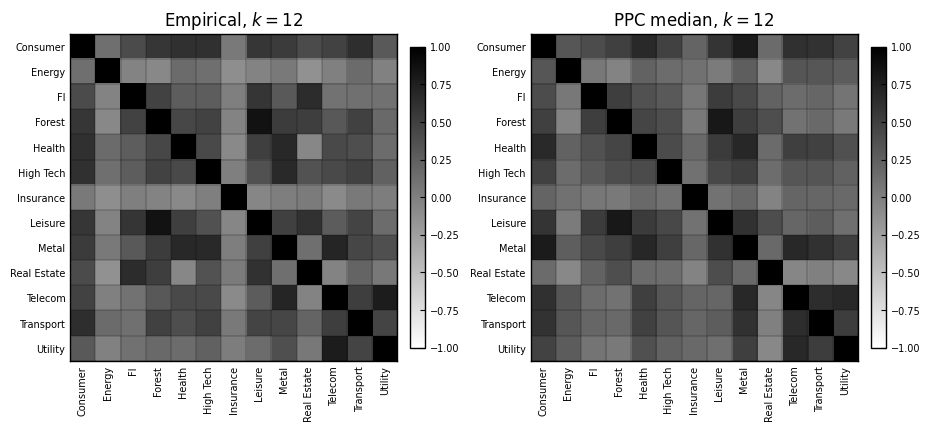

In [6]:
# ============================================================
# Figure 5. Empirical and posterior predictive correlations for k=12
#          grayscale heatmaps, main-text version
# ============================================================

C_emp = corr_outputs[12]["C_emp"]
C_ppc_med = corr_outputs[12]["C_ppc_med"]

fig, axes = plt.subplots(
    1,
    2,
    figsize=(9.2, 4.6),
    constrained_layout=True,
)

mats = [
    C_emp,
    C_ppc_med,
]

titles = [
    r"Empirical, $k=12$",
    r"PPC median, $k=12$",
]

for ax, M, title in zip(axes, mats, titles):
    im = ax.imshow(
        M,
        vmin=-1.0,
        vmax=1.0,
        cmap="gray_r",
        aspect="equal",
    )

    ax.set_title(title, fontsize=12)
    ax.set_xticks(np.arange(D))
    ax.set_yticks(np.arange(D))
    ax.set_xticklabels(sector_labels, rotation=90, fontsize=7)
    ax.set_yticklabels(sector_labels, fontsize=7)
    ax.tick_params(length=0)

    # Thin grid lines improve readability in grayscale.
    ax.set_xticks(np.arange(-0.5, D, 1), minor=True)
    ax.set_yticks(np.arange(-0.5, D, 1), minor=True)
    ax.grid(which="minor", color="black", linestyle="-", linewidth=0.20)
    ax.tick_params(which="minor", bottom=False, left=False)

    cbar = fig.colorbar(im, ax=ax, fraction=0.046, pad=0.04)
    cbar.ax.tick_params(labelsize=7)

save_figure(fig, "fig05_correlation_matrices_k12_grayscale_main")
plt.show()


Saved: figures\fig06_F1_F2_posterior_mean_trajectory_grayscale.png
Saved: figures\fig06_F1_F2_posterior_mean_trajectory_grayscale.pdf


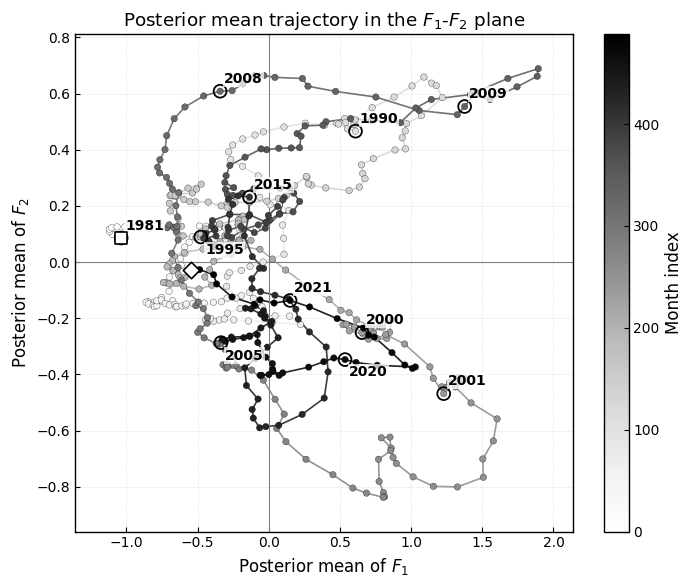

In [7]:
# ============================================================
# Figure 6. Posterior mean trajectory in the F1-F2 plane
#           grayscale version for manuscript
# ============================================================

from matplotlib.collections import LineCollection
from matplotlib import colors

years_to_label = [1981, 1990, 1995, 2000, 2001, 2005, 2008, 2009, 2015, 2020, 2021]
label_offsets = {
    1981: (0.03, 0.03),
    1985: (0.03, -0.06),
    1990: (0.03, 0.03),
    1995: (0.03, -0.06),
    2000: (0.03, 0.03),
    2005: (0.03, -0.06),
    2008: (0.03, 0.03),
    2009: (0.03, 0.03),
    2010: (0.03, -0.06),
    2015: (0.03, 0.03),
    2020: (0.03, -0.06),
    2021: (0.03, 0.03),
}
time_index = np.arange(len(F1_mean_t))
plot_dates = date_index[:len(F1_mean_t)]

# ------------------------------------------------------------
# Build line segments for grayscale time-gradient trajectory
# ------------------------------------------------------------
points = np.column_stack([F1_mean_t, F2_mean_t]).reshape(-1, 1, 2)
segments = np.concatenate([points[:-1], points[1:]], axis=1)

time_norm = colors.Normalize(vmin=time_index.min(), vmax=time_index.max())


fig, ax = plt.subplots(figsize=(7.2, 6.0))

# Trajectory line with grayscale gradient
lc = LineCollection(
    segments,
    cmap="Greys",
    norm=time_norm,
    linewidths=1.2,
    alpha=0.9,
)
lc.set_array(time_index[:-1])
ax.add_collection(lc)

# Scatter points on top of the line
sc = ax.scatter(
    F1_mean_t,
    F2_mean_t,
    c=time_index,
    cmap="Greys",
    norm=time_norm,
    s=22,
    edgecolors="black",
    linewidths=0.2,
    zorder=3,
)

# ------------------------------------------------------------
# Highlight selected years
# ------------------------------------------------------------
for year in years_to_label:
    idx_year = np.where(plot_dates.year == year)[0]
    if len(idx_year) == 0:
        continue

    t0 = int(idx_year[0])
    dx, dy = label_offsets.get(year, (0.03, 0.03))

    ax.scatter(
        F1_mean_t[t0],
        F2_mean_t[t0],
        s=85,
        marker="o",
        facecolor="none",
        edgecolor="black",
        linewidth=1.3,
        zorder=5,
    )

    ax.text(
        F1_mean_t[t0] + dx,
        F2_mean_t[t0] + dy,
        str(year),
        fontsize=10,
        fontweight="bold",
        color="black",
        zorder=6,
        bbox=dict(
            facecolor="white",
            edgecolor="none",
            alpha=0.75,
            pad=0.8,
        ),
    )


# ------------------------------------------------------------
# Mark start and end points explicitly
# ------------------------------------------------------------
ax.scatter(
    F1_mean_t[0],
    F2_mean_t[0],
    s=70,
    marker="s",
    facecolor="white",
    edgecolor="black",
    linewidth=1.2,
    zorder=6,
)

ax.scatter(
    F1_mean_t[-1],
    F2_mean_t[-1],
    s=70,
    marker="D",
    facecolor="white",
    edgecolor="black",
    linewidth=1.2,
    zorder=6,
)


# ------------------------------------------------------------
# Axes and guides
# ------------------------------------------------------------
ax.axhline(0.0, color="gray", linewidth=0.8, linestyle="-")
ax.axvline(0.0, color="gray", linewidth=0.8, linestyle="-")

ax.set_xlabel("Posterior mean of $F_1$")
ax.set_ylabel("Posterior mean of $F_2$")
ax.set_title("Posterior mean trajectory in the $F_1$-$F_2$ plane")

ax.grid(True, linestyle=":", linewidth=0.5, alpha=0.6)

# Slight padding around data range
xpad = 0.08 * (np.max(F1_mean_t) - np.min(F1_mean_t))
ypad = 0.08 * (np.max(F2_mean_t) - np.min(F2_mean_t))
ax.set_xlim(np.min(F1_mean_t) - xpad, np.max(F1_mean_t) + xpad)
ax.set_ylim(np.min(F2_mean_t) - ypad, np.max(F2_mean_t) + ypad)

# Colorbar in grayscale
cbar = fig.colorbar(sc, ax=ax)
cbar.set_label("Month index")

fig.tight_layout()
save_figure(fig, "fig06_F1_F2_posterior_mean_trajectory_grayscale")
plt.show()

# Save trajectory data table
pd.DataFrame({
    "date": plot_dates,
    "F1_mean": F1_mean_t,
    "F2_mean": F2_mean_t,
}).to_csv(
    TABLE_DIR / "table_F1_F2_posterior_mean_trajectory.csv",
    index=False,
)


Computing eigenvalue scaling for k=1
Computing eigenvalue scaling for k=2
Computing eigenvalue scaling for k=3
Computing eigenvalue scaling for k=4
Computing eigenvalue scaling for k=6
Computing eigenvalue scaling for k=12


,rank,eigenvalue_scaling_rmse
0,1,0.156967
1,2,0.146132
2,3,0.054199
3,4,0.062886


Saved: figures\eigenvalue_scaling_k1_to_k12.png
Saved: figures\eigenvalue_scaling_k1_to_k12.pdf


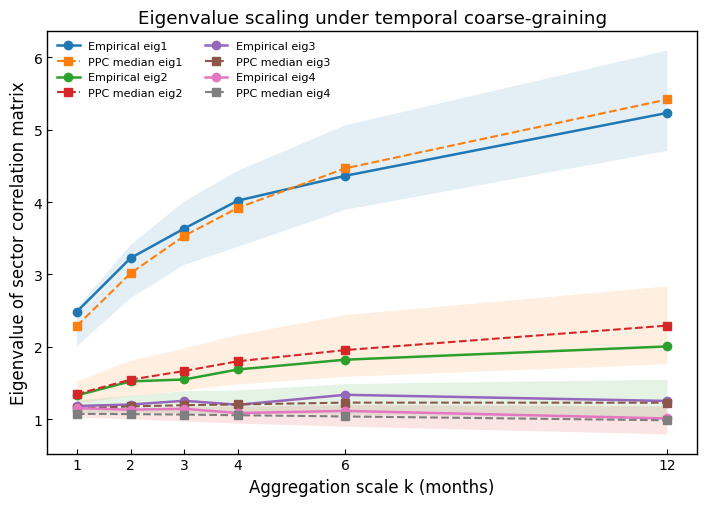

In [8]:
# ============================================================
# Eigenvalue scaling diagnostics
# ============================================================

eig_records = []
for k in K_LIST:
    print(f"Computing eigenvalue scaling for k={k}")
    C_emp = safe_corrcoef(empirical_rate_matrix(k))
    eig_emp = np.linalg.eigvalsh(C_emp)[::-1]

    if k in corr_outputs:
        eig_ppc_draws = corr_outputs[k]["eig_ppc_draws"]
    else:
        _, eig_ppc_draws = posterior_predictive_corr_draws(k, p_paths, rng)

    q025, q500, q975 = np.nanquantile(eig_ppc_draws, [0.025, 0.5, 0.975], axis=0)
    for r in range(D):
        eig_records.append({
            "k_month": k,
            "rank": r + 1,
            "eig_empirical": eig_emp[r],
            "eig_ppc_q025": q025[r],
            "eig_ppc_median": q500[r],
            "eig_ppc_q975": q975[r],
        })

df_eig_scaling = pd.DataFrame(eig_records)
df_eig_scaling.to_csv(TABLE_DIR / "table_eigenvalue_scaling_k1_to_k12.csv", index=False)

# RMSE for ranks 1--4.
rmse_rows = []
for r in [1, 2, 3, 4]:
    g = df_eig_scaling.query("rank == @r")
    rmse_rows.append({
        "rank": r,
        "eigenvalue_scaling_rmse": float(np.sqrt(np.mean((g["eig_ppc_median"] - g["eig_empirical"]) ** 2))),
    })
df_eig_rmse = pd.DataFrame(rmse_rows)
df_eig_rmse.to_csv(TABLE_DIR / "table_eigenvalue_scaling_rmse_ranks1_to4.csv", index=False)
display(df_eig_rmse)

fig, ax = plt.subplots(figsize=(7.2, 5.2))
for r in [1, 2, 3, 4]:
    g = df_eig_scaling.query("rank == @r").sort_values("k_month")
    ax.plot(g["k_month"], g["eig_empirical"], marker="o", linewidth=1.8, label=f"Empirical eig{r}")
    ax.plot(g["k_month"], g["eig_ppc_median"], marker="s", linestyle="--", linewidth=1.5, label=f"PPC median eig{r}")
    ax.fill_between(g["k_month"].to_numpy(), g["eig_ppc_q025"].to_numpy(), g["eig_ppc_q975"].to_numpy(), alpha=0.12)

ax.set_xlabel("Aggregation scale k (months)")
ax.set_ylabel("Eigenvalue of sector correlation matrix")
ax.set_title("Eigenvalue scaling under temporal coarse-graining")
ax.set_xticks(K_LIST)
ax.legend(ncol=2, frameon=False, fontsize=8)
fig.tight_layout()
save_figure(fig, "eigenvalue_scaling_k1_to_k12")
plt.show()


Selected pairs:


,sector_i,sector_j,i,j,cov_common,corr_common
69,Metal,Telecom,8,10,0.060230,0.878587
72,Real Estate,Telecom,9,10,-0.008618,-0.178553


k=1: z_k shape = (800, 489, 13)
k=12: z_k shape = (800, 40, 13)
Saved: figures\fig07_rank_copula_positive_common_component_covariance_Metal_Telecom.png
Saved: figures\fig07_rank_copula_positive_common_component_covariance_Metal_Telecom.pdf


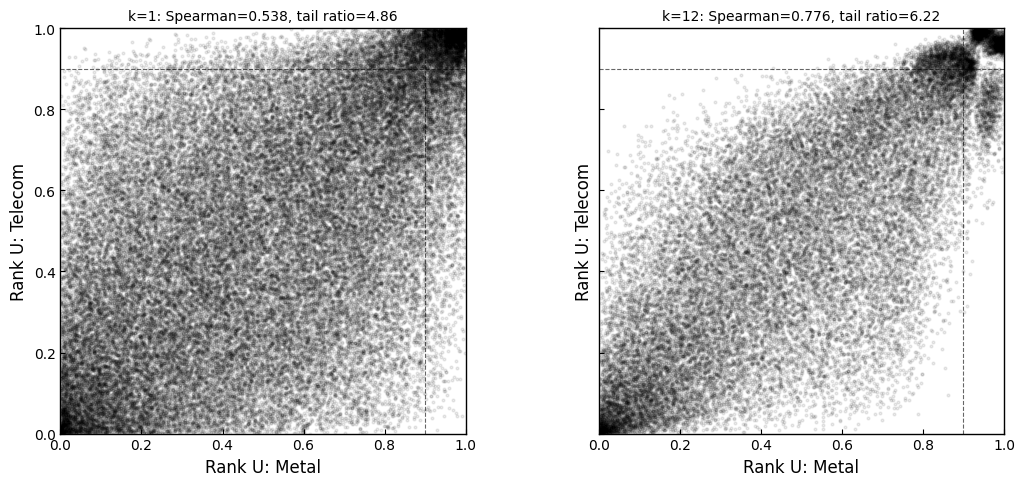

Saved: figures\fig07_rank_copula_negative_common_component_covariance_Real_Estate_Telecom.png
Saved: figures\fig07_rank_copula_negative_common_component_covariance_Real_Estate_Telecom.pdf


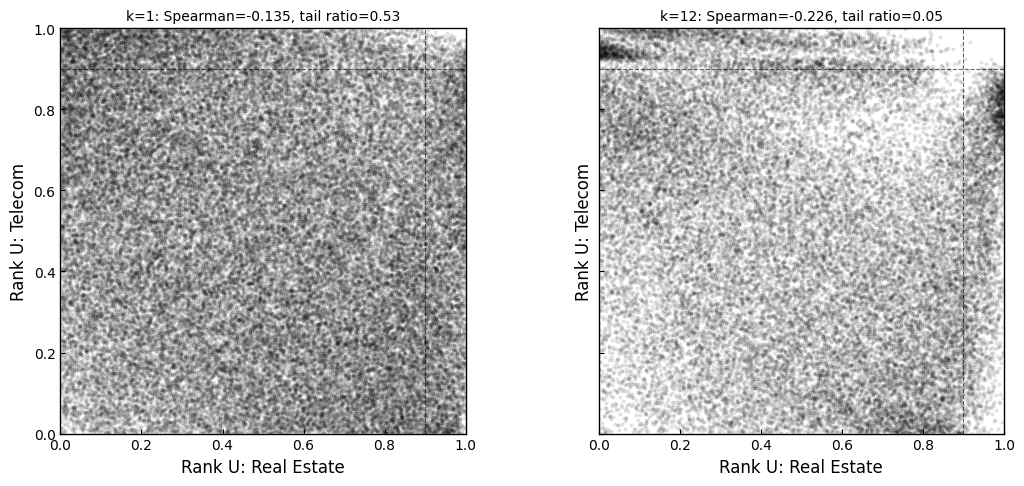

,pair_label,sector_i,sector_j,k_month,spearman_corr,upper_tail_ratio_q90
0,Positive common-component covariance,Metal,Telecom,1,0.537504,4.862219
1,Positive common-component covariance,Metal,Telecom,12,0.775516,6.221875
2,Negative common-component covariance,Real Estate,Telecom,1,-0.134819,0.532209
3,Negative common-component covariance,Real Estate,Telecom,12,-0.225996,0.053125


In [9]:
# ============================================================
# Figure 7. Representative posterior-implied rank copulas
#          standalone version, no dependency on projection_results
# ============================================================

# Select sector pairs using the covariance of the low-rank common component
# common_{t,s} = lambda_{s1} F1_t + lambda_{s2} F2_t.
from scipy.stats import norm

lambda1 = Lambda_fixed[:, 0]
lambda2 = Lambda_fixed[:, 1]

common_factor_part = (
    F1_mean_t[:, None] * lambda1[None, :]
    + F2_mean_t[:, None] * lambda2[None, :]
)

C_common = np.cov(common_factor_part, rowvar=False)

pair_rows = []

for i in range(D):
    for j in range(i + 1, D):
        cov_ij = C_common[i, j]

        denom = np.sqrt(C_common[i, i] * C_common[j, j])
        if denom > 0:
            corr_ij = cov_ij / denom
        else:
            corr_ij = np.nan

        pair_rows.append({
            "sector_i": sector_labels[i],
            "sector_j": sector_labels[j],
            "i": i,
            "j": j,
            "cov_common": cov_ij,
            "corr_common": corr_ij,
        })

df_common_cov_pairs = pd.DataFrame(pair_rows)
df_common_cov_pairs.to_csv(
    TABLE_DIR / "table_low_rank_common_component_pair_covariances.csv",
    index=False,
)

pos_pair = df_common_cov_pairs.sort_values(
    "cov_common", ascending=False
).iloc[0]

neg_pair = df_common_cov_pairs.sort_values(
    "cov_common", ascending=True
).iloc[0]

selected_pairs = [("Positive common-component covariance", pos_pair)]

if neg_pair["cov_common"] < 0:
    selected_pairs.append(("Negative common-component covariance", neg_pair))

print("Selected pairs:")
display(pd.DataFrame([p for _, p in selected_pairs]))


# ------------------------------------------------------------
# Helper functions
# ------------------------------------------------------------

def posterior_z_for_k(k, p_paths, eps=P_MIN):
    """
    Return probit-scale posterior sector probability paths at horizon k.

    Output shape:
        S x B_k x D

    where S is posterior draw index, B_k is block index, and D is sector index.
    """
    p_k = coarse_grain_prob_paths(p_paths, k=k)
    z_k = norm.ppf(np.clip(p_k, eps, 1.0 - eps))
    return z_k


def rank_copula_arrays(z_k, i, j):
    """
    Construct rank-copula samples from probit-scale sector latent states.

    z_k has shape S x B_k x D.
    The posterior draws and time blocks are pooled before rank transformation.
    """
    x_all = np.asarray(z_k[:, :, i]).reshape(-1)
    y_all = np.asarray(z_k[:, :, j]).reshape(-1)

    mask = np.isfinite(x_all) & np.isfinite(y_all)
    x_all = x_all[mask]
    y_all = y_all[mask]

    n_all = len(x_all)

    u_all = rankdata(x_all, method="average") / (n_all + 1.0)
    v_all = rankdata(y_all, method="average") / (n_all + 1.0)

    return u_all, v_all


# ------------------------------------------------------------
# Precompute z_k for k=1 and k=12
# ------------------------------------------------------------

z_by_k = {}

for k in [1, 12]:
    z_by_k[k] = posterior_z_for_k(k, p_paths, eps=P_MIN)
    print(f"k={k}: z_k shape = {z_by_k[k].shape}")


# ------------------------------------------------------------
# Plot representative rank copulas
# ------------------------------------------------------------

summary_rows = []

for pair_label, pair_row in selected_pairs:
    i = int(pair_row["i"])
    j = int(pair_row["j"])

    s_i = sector_labels[i]
    s_j = sector_labels[j]

    fig, axes = plt.subplots(
        1,
        2,
        figsize=(11.2, 5.0),
        sharex=True,
        sharey=True,
    )

    for ax, k in zip(axes, [1, 12]):
        z_k = z_by_k[k]

        u_all, v_all = rank_copula_arrays(z_k, i, j)

        spearman_corr = float(np.corrcoef(u_all, v_all)[0, 1])

        q = 0.90
        upper_tail_prob = np.mean((u_all > q) & (v_all > q))
        tail_ratio = float(upper_tail_prob / ((1.0 - q) ** 2))

        summary_rows.append({
            "pair_label": pair_label,
            "sector_i": s_i,
            "sector_j": s_j,
            "k_month": k,
            "spearman_corr": spearman_corr,
            "upper_tail_ratio_q90": tail_ratio,
        })

        n_all = len(u_all)

        if n_all > MAX_COPULA_POINTS:
            idx = rng.choice(n_all, size=MAX_COPULA_POINTS, replace=False)
            u = u_all[idx]
            v = v_all[idx]
        else:
            u = u_all
            v = v_all

        ax.scatter(
            u,
            v,
            s=4,
            alpha=0.08,
            color="black",
            rasterized=True,
        )

        ax.axhline(
            q,
            color="black",
            linewidth=0.8,
            alpha=0.6,
            linestyle="--",
        )
        ax.axvline(
            q,
            color="black",
            linewidth=0.8,
            alpha=0.6,
            linestyle="--",
        )

        ax.set_xlim(0, 1)
        ax.set_ylim(0, 1)
        ax.set_aspect("equal", adjustable="box")

        ax.set_xlabel(f"Rank U: {s_i}")
        ax.set_ylabel(f"Rank U: {s_j}")

        ax.set_title(
            f"k={k}: Spearman={spearman_corr:.3f}, "
            f"tail ratio={tail_ratio:.2f}",
            fontsize=10,
        )


    fig.tight_layout()

    safe_label = (
        pair_label.lower()
        .replace(" ", "_")
        .replace("-", "_")
    )
    safe_s1 = s_i.replace(" ", "_").replace("/", "_")
    safe_s2 = s_j.replace(" ", "_").replace("/", "_")

    save_figure(
        fig,
        f"fig07_rank_copula_{safe_label}_{safe_s1}_{safe_s2}",
    )

    plt.show()


df_rank_copula_summary = pd.DataFrame(summary_rows)

df_rank_copula_summary.to_csv(
    TABLE_DIR / "table_representative_rank_copula_summary.csv",
    index=False,
)

display(df_rank_copula_summary)


## Notes for public release

This notebook expects the R=2 common-eps posterior NetCDF file generated by `03_factor_selection_common_eps.ipynb`.

For public GitHub use, run the notebooks in order:

```text
01_generate_synthetic_multisector_data.ipynb
02_data_coarse_graining.ipynb
03_factor_selection_common_eps.ipynb
04_diagnostics_R2_common_eps.ipynb
```

With `SAMPLE.csv`, the outputs are only workflow demonstrations. With the proprietary real data placed at `./data/SP_monthly_sector_and_all.csv`, the same notebook regenerates the empirical paper figures.
